In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from collections.abc import Mapping
from IPython.display import display
from plotting_utils import (
    get_nice_prompt_name,
    get_short_model_name,
    extract_prompt_version,
)

# Read in the data from the results json files

In [2]:
# This is where we'll want to add something like "Structured rules"
PROMPT_MAPPING = {
    "Accuracy-ChildBenefit-structuredOutput-v2.md": "Rules in URLs",
    "Accuracy-ChildBenefit-structuredOutput-v2.1_no_links.md": "Training data only",
    "Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md": "Rules in prompt",
}

In [3]:
def create_df_runs(
    test_cohort: str = "child_benefit", drop_unknown_prompt: bool = True
) -> pd.DataFrame:
    reports_dir = Path(f"testOutputs/{test_cohort}/eval_reports")
    run_data = []
    for run_dir in reports_dir.iterdir():
        if not run_dir.is_dir():
            continue

        summary_path = run_dir / "evaluation_report_summary.json"
        cases_path = run_dir / "evaluation_report_cases.json"

        if summary_path.exists() and cases_path.exists():
            with open(summary_path, "r") as f:
                summary = json.load(f)
            with open(cases_path, "r") as f:
                cases = json.load(f)

            config = summary.get("run_config", {})

            run_data.append(
                {
                    "run_name": run_dir.name,
                    "model": config.get("eligibility_model_string", "unknown"),
                    "prompt": config.get("eligibility_prompt", "unknown"),
                    "url_allowed": config.get("url_tool_call_allowed", True),
                    "commit": config.get("commit", "unknown"),
                    "results": cases.get(
                        "results", cases
                    ),  # Handles nested (old style) or flat cases dict
                }
            )

    df_runs = pd.DataFrame(run_data)

    # From before we recorded the prompt in this way and have different shaped output
    if drop_unknown_prompt:
        df_runs = (df_runs[df_runs["prompt"] != "unknown"]).reset_index()

    # Create some slightly shorter/nicer names for plotting/tables
    df_runs[["prompt_name", "prompt_type"]] = (
        df_runs["prompt"]
        .apply(lambda p: get_nice_prompt_name(p, PROMPT_MAPPING))
        .apply(pd.Series)
    )
    df_runs["model_name"] = df_runs["model"].apply(get_short_model_name)

    df_runs["config_key"] = df_runs.apply(
        lambda x: (x["model_name"], x["prompt_name"], x["url_allowed"]), axis=1
    )

    df_runs["prompt_version"] = df_runs["prompt_name"].apply(extract_prompt_version)

    # Can't plot full prompt name - it breaks the axes
    df_runs["config_label"] = (
        df_runs["model_name"]
        + " | "
        + df_runs["prompt_type"]
        + " | "
        + df_runs["url_allowed"].map({True: "URLs ON", False: "URLs OFF"})
    )
    print("df_runs created and its head looks like this:")
    display(df_runs.head())

    print("Configurations found and their run counts:")
    display(df_runs["config_key"].value_counts().to_frame("Count"))

    return df_runs


df_runs = create_df_runs()

df_runs created and its head looks like this:


,index,run_name,model,prompt,url_allowed,commit,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,1,2026-03-10T17:32:39.329093__Model=claude-sonne...,bedrock/converse/eu.anthropic.claude-sonnet-4-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,55b2687,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.2_no...,Rules in prompt,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-stru...",v2.2,claude-sonnet-4-5 | Rules in prompt | URLs OFF
1,2,2026-03-05T18:24:18.571514__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,True,63c7add,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.md,Rules in URLs,claude-opus-4-5,"(claude-opus-4-5, Accuracy-ChildBenefit-struct...",v2,claude-opus-4-5 | Rules in URLs | URLs ON
2,3,2026-03-10T19:32:27.754210__Model=claude-sonne...,bedrock/converse/eu.anthropic.claude-sonnet-4-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,55b2687,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.2_no...,Rules in prompt,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-stru...",v2.2,claude-sonnet-4-5 | Rules in prompt | URLs OFF
3,4,2026-03-04T20:18:49.825618__Model=claude-sonne...,bedrock/converse/eu.anthropic.claude-sonnet-4-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,True,4ce9578,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.md,Rules in URLs,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-stru...",v2,claude-sonnet-4-5 | Rules in URLs | URLs ON
4,5,2026-03-06T16:14:17.738276__Model=claude-haiku...,bedrock/converse/eu.anthropic.claude-haiku-4-5...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,de4cbdf,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.2_no...,Rules in prompt,claude-haiku-4-5,"(claude-haiku-4-5, Accuracy-ChildBenefit-struc...",v2.2,claude-haiku-4-5 | Rules in prompt | URLs OFF


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",5
"(claude-sonnet-4-5, Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md, False)",4
"(claude-opus-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",1
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md, False)",1
"(claude-sonnet-4-5, Accuracy-ChildBenefit-structuredOutput-v2.1_no_links.md, False)",1
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",1
"(claude-opus-4-5, Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md, False)",1


# Get the data into shape to plot accuracy and latency

In [4]:
def flatten_run_row(row) -> list[dict]:
    run_name = row.run_name
    timestamp_str = run_name.split("__")[0]

    model_string = str(row.model)
    if model_string.lower() == "unknown":
        return []

    results = row.results
    if not isinstance(results, Mapping):
        return []

    output = []

    for case_id, case_data in results.items():
        if case_id == "run_config":
            continue

        duration = case_data.get("duration_seconds")
        if duration is None:
            continue

        output.append(
            {
                "run_name": run_name,
                "timestamp": pd.to_datetime(timestamp_str),
                "config_label": row.config_label,
                "case_id": case_id,
                "is_correct": int(case_data.get("overall_is_correct", False)),
                "duration": float(duration),
            }
        )

    return output


def flatten_runs(df_runs: pd.DataFrame) -> pd.DataFrame:
    flat_data = [
        record
        for row in df_runs.itertuples(index=False)
        for record in flatten_run_row(row)
    ]

    return pd.DataFrame(flat_data)


In [5]:
df_flat = flatten_runs(df_runs)

print(f"Flattened dataset: {len(df_flat)} total case evaluations.")
display(
    df_flat[["run_name", "config_label", "case_id", "is_correct", "duration"]].head()
)

Flattened dataset: 1287 total case evaluations.


,run_name,config_label,case_id,is_correct,duration
0,2026-03-10T17:32:39.329093__Model=claude-sonne...,claude-sonnet-4-5 | Rules in prompt | URLs OFF,MULTI_MIXED_THREE_MIXED,1,33.89
1,2026-03-10T17:32:39.329093__Model=claude-sonne...,claude-sonnet-4-5 | Rules in prompt | URLs OFF,RESIDENCY_FAIL_MULTI,1,39.83
2,2026-03-10T17:32:39.329093__Model=claude-sonne...,claude-sonnet-4-5 | Rules in prompt | URLs OFF,RND_047,1,28.12
3,2026-03-10T17:32:39.329093__Model=claude-sonne...,claude-sonnet-4-5 | Rules in prompt | URLs OFF,RESPONSIBILITY_PASS_UPKEEP_SUFFICIENT,1,31.33
4,2026-03-10T17:32:39.329093__Model=claude-sonne...,claude-sonnet-4-5 | Rules in prompt | URLs OFF,RND_023,1,51.22


# Plot latency

In [6]:
def plot_latency_by_configuration(
    df_flat: pd.DataFrame,
    upper_quantile: float = 0.99,
) -> None:
    df_plot = df_flat.copy()

    label_order = (
        df_plot.groupby("config_label")["duration"]
        .median()
        .sort_values()
        .index.tolist()
    )

    palette = dict(
        zip(label_order, sns.color_palette("Set2", n_colors=len(label_order)))
    )

    # Exclude only very high durations from the plot
    upper_bound = df_plot["duration"].quantile(upper_quantile)
    df_plot_trimmed = df_plot.loc[df_plot["duration"] <= upper_bound].copy()

    fig, ax = plt.subplots(figsize=(12, 7))

    sns.violinplot(
        data=df_plot_trimmed,
        x="duration",
        y="config_label",
        hue="config_label",
        order=label_order,
        hue_order=label_order,
        palette=palette,
        inner="quartile",
        cut=0,
        dodge=False,
        legend=False,
        ax=ax,
    )

    sns.stripplot(
        data=df_plot_trimmed,
        x="duration",
        y="config_label",
        hue="config_label",
        order=label_order,
        hue_order=label_order,
        palette=palette,
        dodge=False,
        legend=False,
        size=4,
        jitter=0.18,
        alpha=0.7,
        linewidth=0.3,
        edgecolor="black",
        ax=ax,
    )

    ax.set_title("Distribution of Case Latency by Configuration", fontsize=14)
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("")

    excluded_count = len(df_plot) - len(df_plot_trimmed)
    if excluded_count > 0:
        ax.set_title(
            f"Distribution of Case Latency by Configuration\n"
            f"(excluding {excluded_count} high outlier points above the {upper_quantile:.0%} percentile)",
            fontsize=14,
        )

    plt.tight_layout()
    plt.show()

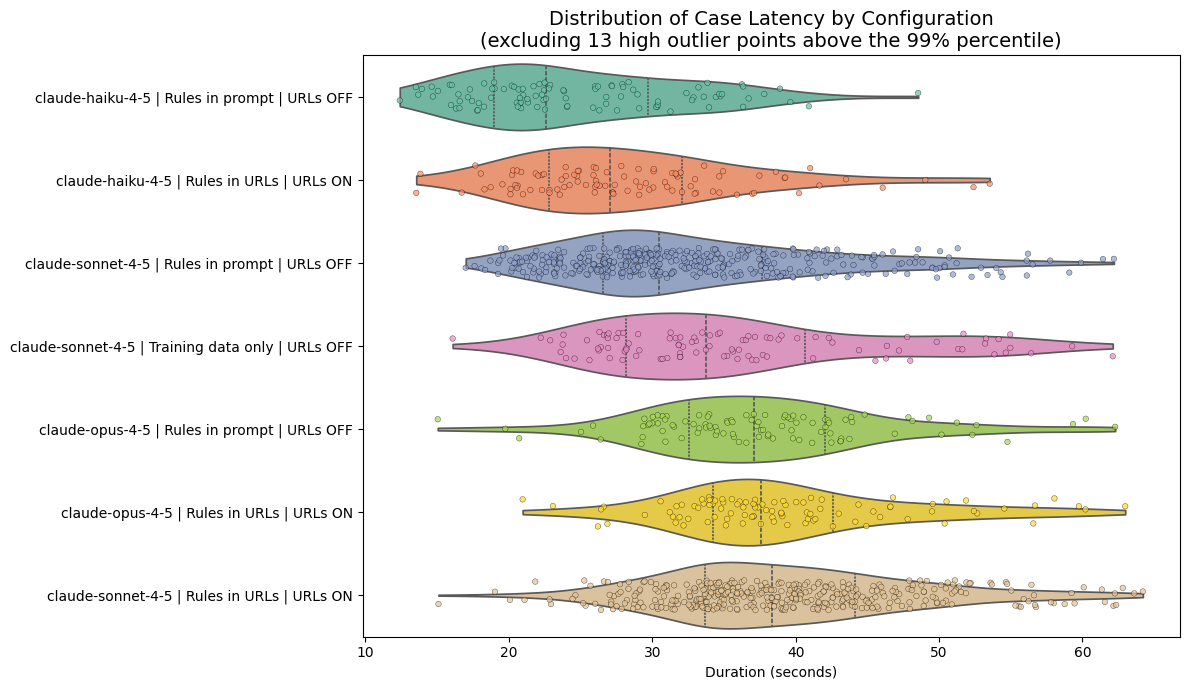

In [7]:
plot_latency_by_configuration(df_flat)


# Plot accuracy

In [8]:
def plot_accuracy_by_configuration(df_flat: pd.DataFrame) -> None:
    df_plot = df_flat

    # Order bars by accuracy
    accuracy_order = (
        df_plot.groupby("config_label")["is_correct"]
        .mean()
        .sort_values()
        .index.tolist()
    )

    palette = dict(
        zip(accuracy_order, sns.color_palette("Set2", n_colors=len(accuracy_order)))
    )

    fig, ax = plt.subplots(figsize=(12, 7))

    sns.barplot(
        data=df_plot,
        x="is_correct",
        y="config_label",
        order=accuracy_order,
        hue="config_label",
        hue_order=accuracy_order,
        palette=palette,
        dodge=False,
        legend=False,
        capsize=0.1,
        ax=ax,
    )

    # Format axis
    ax.set_title("Overall Accuracy by Configuration (with 95% CI)", fontsize=14)
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("")
    ax.set_xlim(0, 1.0)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

    # Add percentage labels to bars
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(
            width + 0.01,
            y - 0.1,
            f"{width:.1%}",
            va="center",
            ha="left",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

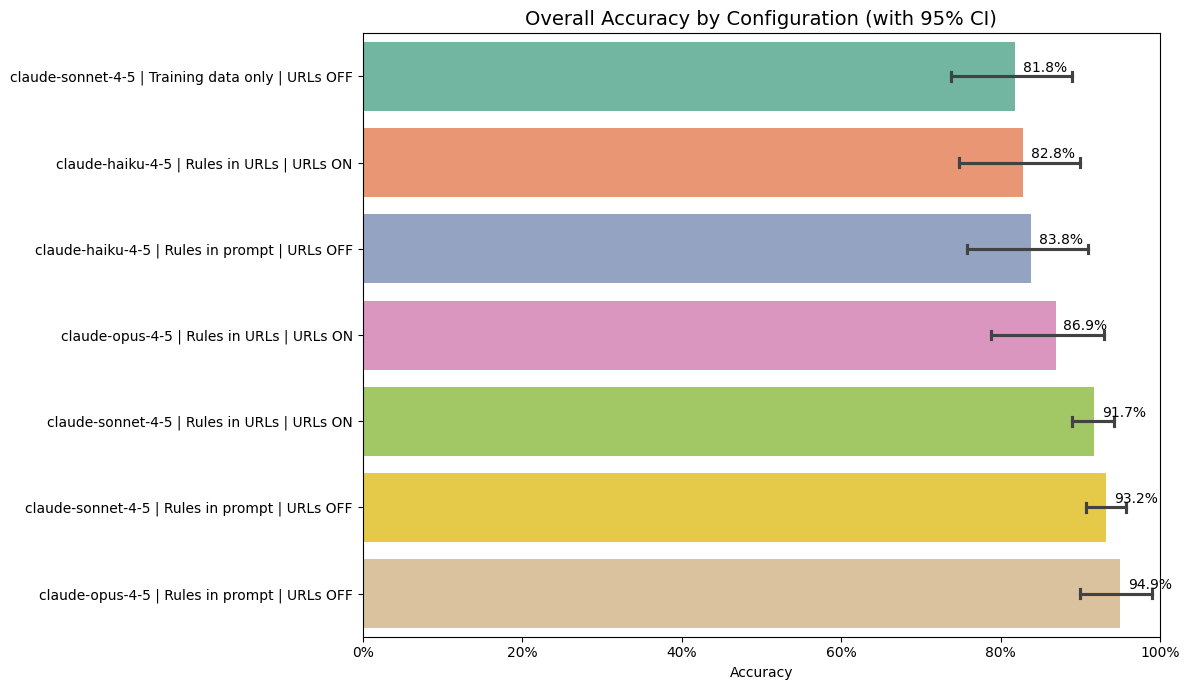

In [9]:
plot_accuracy_by_configuration(df_flat)

# False positives vs false negatives

In [10]:
def get_outcome_category(expected: bool, predicted: bool) -> str:
    if predicted and expected:
        return "True Positive"
    if predicted and not expected:
        return "False Positive"
    if not predicted and expected:
        return "False Negative"
    return "True Negative"


def build_child_outcome_dataframe(df_runs: pd.DataFrame) -> pd.DataFrame:
    """
    Flatten child-level eligibility outcomes from run results.

    Returns a dataframe with one row per child evaluation, containing the
    configuration label and outcome category.
    """
    error_data = []

    for row in df_runs.itertuples(index=False):
        if str(row.model).lower() == "unknown":
            continue

        results = row.results
        if not isinstance(results, Mapping):
            continue

        for case_id, case_result in results.items():
            if case_id == "run_config":
                continue

            child_evaluations = case_result.get("child_evaluations", {})
            if not isinstance(child_evaluations, Mapping):
                continue

            for child_name, child_data in child_evaluations.items():
                expected = child_data.get("expected_eligible")
                predicted = child_data.get("actual_eligible")

                if expected is None or predicted is None:
                    continue

                error_data.append(
                    {
                        "config_label": row.config_label,
                        "case_id": case_id,
                        "child_name": child_name,
                        "outcome_category": get_outcome_category(expected, predicted),
                    }
                )

    return pd.DataFrame(error_data)


def plot_confusion_matrices(df_clean_errors: pd.DataFrame) -> None:
    """
    Plot one percentage confusion matrix per configuration.

    Each heatmap shows the percentage of all evaluated child outcomes for that
    configuration falling into each confusion-matrix cell.
    """
    unique_configs = df_clean_errors["config_label"].unique()

    print(
        f"Generating Percentage Confusion Matrices for {len(unique_configs)} configurations...\n"
    )

    for config in unique_configs:
        df_sub = df_clean_errors.loc[df_clean_errors["config_label"] == config]
        total_cases = len(df_sub)

        if total_cases == 0:
            continue

        counts = df_sub["outcome_category"].value_counts()

        tp = counts.get("True Positive", 0)
        tn = counts.get("True Negative", 0)
        fp = counts.get("False Positive", 0)
        fn = counts.get("False Negative", 0)

        matrix_pct = pd.DataFrame(
            [
                [(tp / total_cases) * 100, (fn / total_cases) * 100],
                [(fp / total_cases) * 100, (tn / total_cases) * 100],
            ],
            index=["Actual Eligible", "Actual Ineligible"],
            columns=["Predicted Eligible", "Predicted Ineligible"],
        )

        fig, ax = plt.subplots(figsize=(7, 5))

        sns.heatmap(
            matrix_pct,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            cbar=False,
            annot_kws={"size": 16, "weight": "bold"},
            linewidths=1,
            linecolor="black",
            ax=ax,
        )

        for text in ax.texts:
            text.set_text(text.get_text() + " %")

        ax.set_title(
            f"Confusion Matrix (% of total evaluated)\n{config}",
            fontsize=14,
            pad=15,
        )
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)

        plt.tight_layout()
        plt.show()

Generating Percentage Confusion Matrices for 7 configurations...



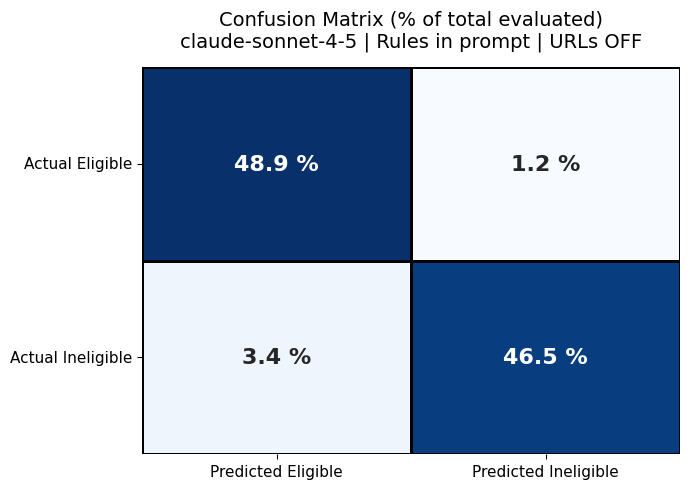

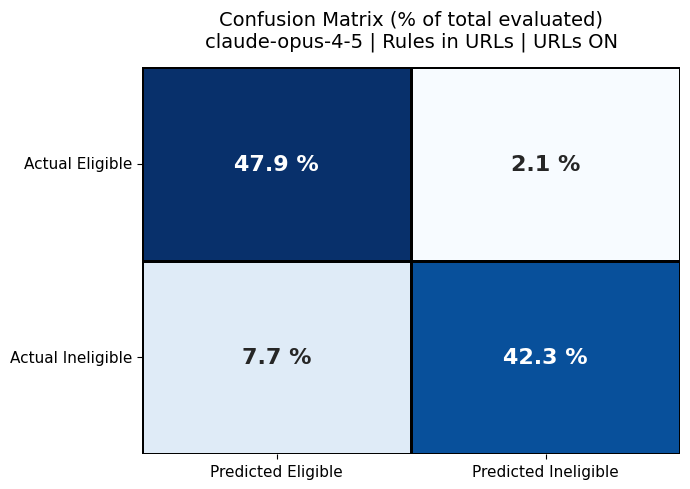

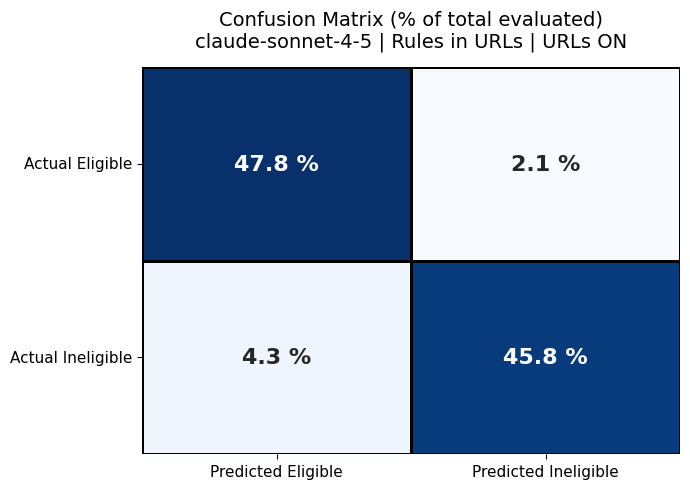

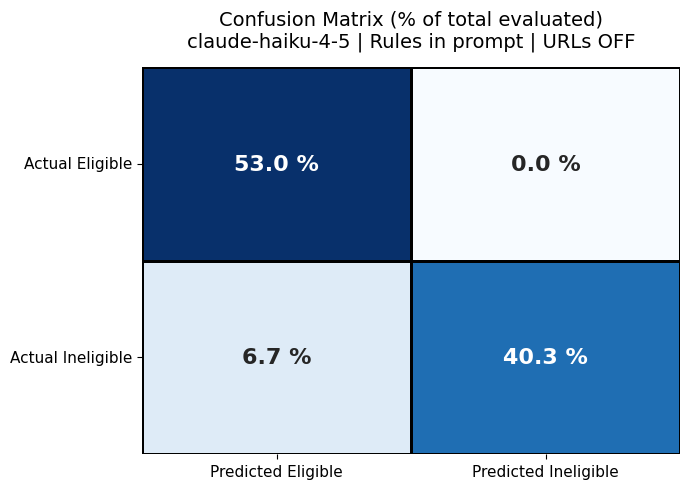

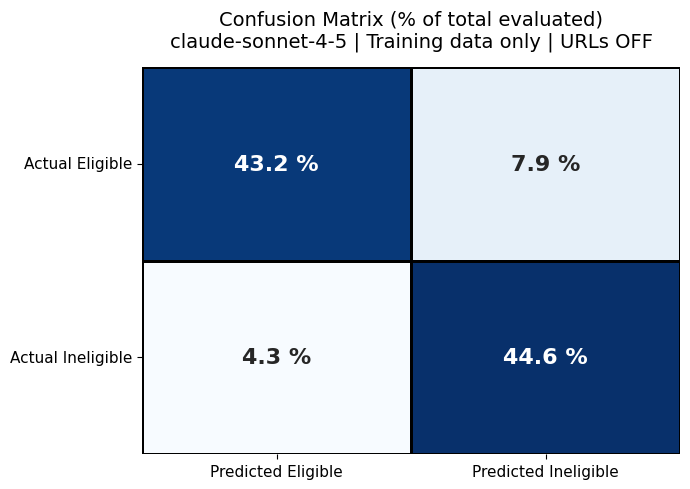

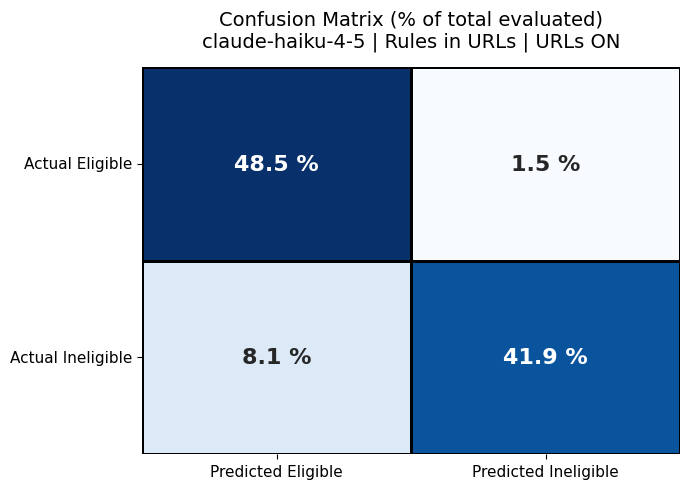

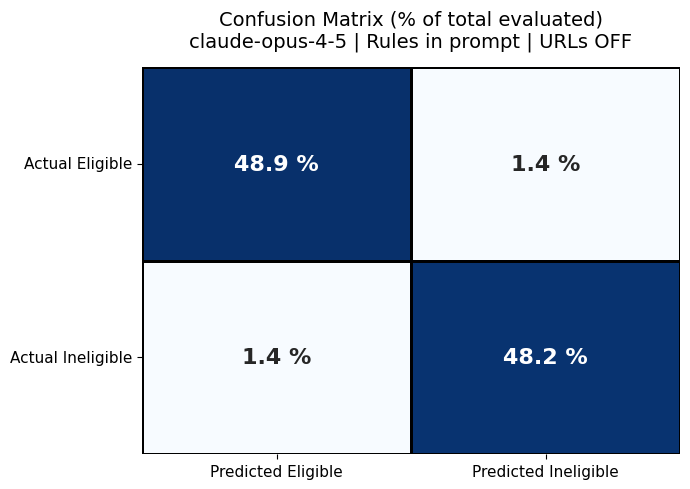

In [11]:
df_clean_errors = build_child_outcome_dataframe(df_runs)
plot_confusion_matrices(df_clean_errors)

# Reliability

Look at repeated results over multiple runs with the same prompt - in this case the most common one.

In [12]:
def build_case_reliability_matrix(target_runs: pd.DataFrame) -> pd.DataFrame:
    """
    Build a pass/fail matrix for one configuration across multiple runs.

    Rows = case IDs
    Columns = run names
    Values = boolean pass/fail
    """
    records: dict[str, dict[str, bool]] = {}

    for row in target_runs.itertuples(index=False):
        run_name = row.run_name
        results = row.results

        if not isinstance(results, Mapping):
            continue

        for case_id, case_data in results.items():
            if case_id == "run_config":
                continue

            if case_id not in records:
                records[case_id] = {}

            records[case_id][run_name] = case_data.get("overall_is_correct", False)

    df_matrix = pd.DataFrame.from_dict(records, orient="index")

    df_matrix["Pass_Rate"] = df_matrix.mean(axis=1)

    df_matrix["Category"] = pd.cut(
        df_matrix["Pass_Rate"],
        bins=[-0.1, 0.0, 0.99, 1.0],
        labels=["Systematic Fail", "Flaky", "Always Passes"],
    )

    return df_matrix


def build_reliability_matrices_by_config(
    df_runs: pd.DataFrame,
    min_runs: int = 3,
) -> dict[tuple, pd.DataFrame]:
    """
    Build one reliability matrix per configuration, keeping only configurations
    with at least `min_runs` runs.
    """
    config_counts = df_runs["config_key"].value_counts()
    eligible_config_keys = config_counts[config_counts >= min_runs].index.tolist()

    matrices = {}

    for config_key in eligible_config_keys:
        target_runs = df_runs.loc[df_runs["config_key"] == config_key]
        matrices[config_key] = build_case_reliability_matrix(target_runs)

    return matrices

In [13]:
reliability_matrices = build_reliability_matrices_by_config(df_runs, min_runs=3)

for config_key, df_matrix in reliability_matrices.items():
    print(f"\n=== Reliability Summary: {config_key} ===")
    display(df_matrix["Category"].value_counts().to_frame("Number of Cases"))

    hard_cases = df_matrix[df_matrix["Pass_Rate"] < 1.0].sort_values("Pass_Rate")
    if not hard_cases.empty:
        print("\n🚨 Flaky and Failing Cases:")
        display(hard_cases[["Pass_Rate", "Category"]].head(10))


=== Reliability Summary: ('claude-sonnet-4-5', 'Accuracy-ChildBenefit-structuredOutput-v2.md', True) ===


,Number of Cases
Category,
Always Passes,69
Flaky,30
Systematic Fail,0



🚨 Flaky and Failing Cases:


,Pass_Rate,Category
FOSTER_FAIL_COUNCIL_PAYS,0.4,Flaky
RND_037,0.4,Flaky
AGE_PASS_17_IN_EXTENSION,0.4,Flaky
RND_046,0.4,Flaky
CHILD_BENEFITS_FAIL_RECEIVES_BENEFITS,0.4,Flaky
HOSPITAL_FAIL_OVER_12_WEEKS_NOT_SPENDING,0.6,Flaky
RND_049,0.6,Flaky
RND_015,0.6,Flaky
RND_040,0.6,Flaky
MULTI_MIXED_THREE_MIXED,0.6,Flaky



=== Reliability Summary: ('claude-sonnet-4-5', 'Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md', False) ===


,Number of Cases
Category,
Always Passes,83
Flaky,14
Systematic Fail,2



🚨 Flaky and Failing Cases:


,Pass_Rate,Category
RND_040,0.00,Systematic Fail
RND_015,0.00,Systematic Fail
MULTI_MIXED_THREE_MIXED,0.50,Flaky
RND_046,0.50,Flaky
CARE_PASS_EXACTLY_8_WEEKS,0.50,Flaky
RND_036,0.50,Flaky
CARE_FAIL_OVER_8_WEEKS_NOT_HOME,0.50,Flaky
CHILD_BENEFITS_FAIL_RECEIVES_BENEFITS,0.75,Flaky
RND_049,0.75,Flaky
HOSPITAL_FAIL_OVER_12_WEEKS_NOT_SPENDING,0.75,Flaky


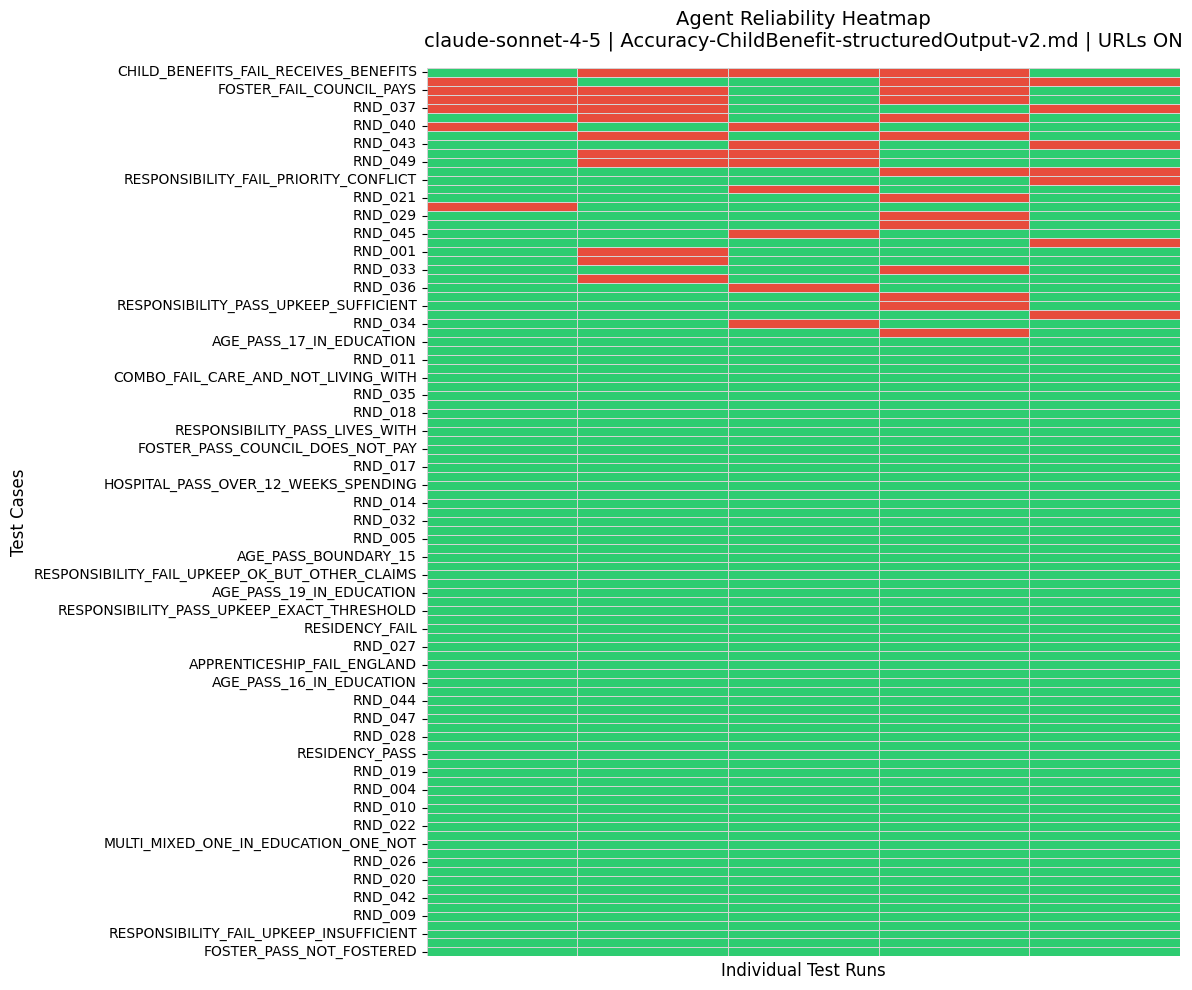

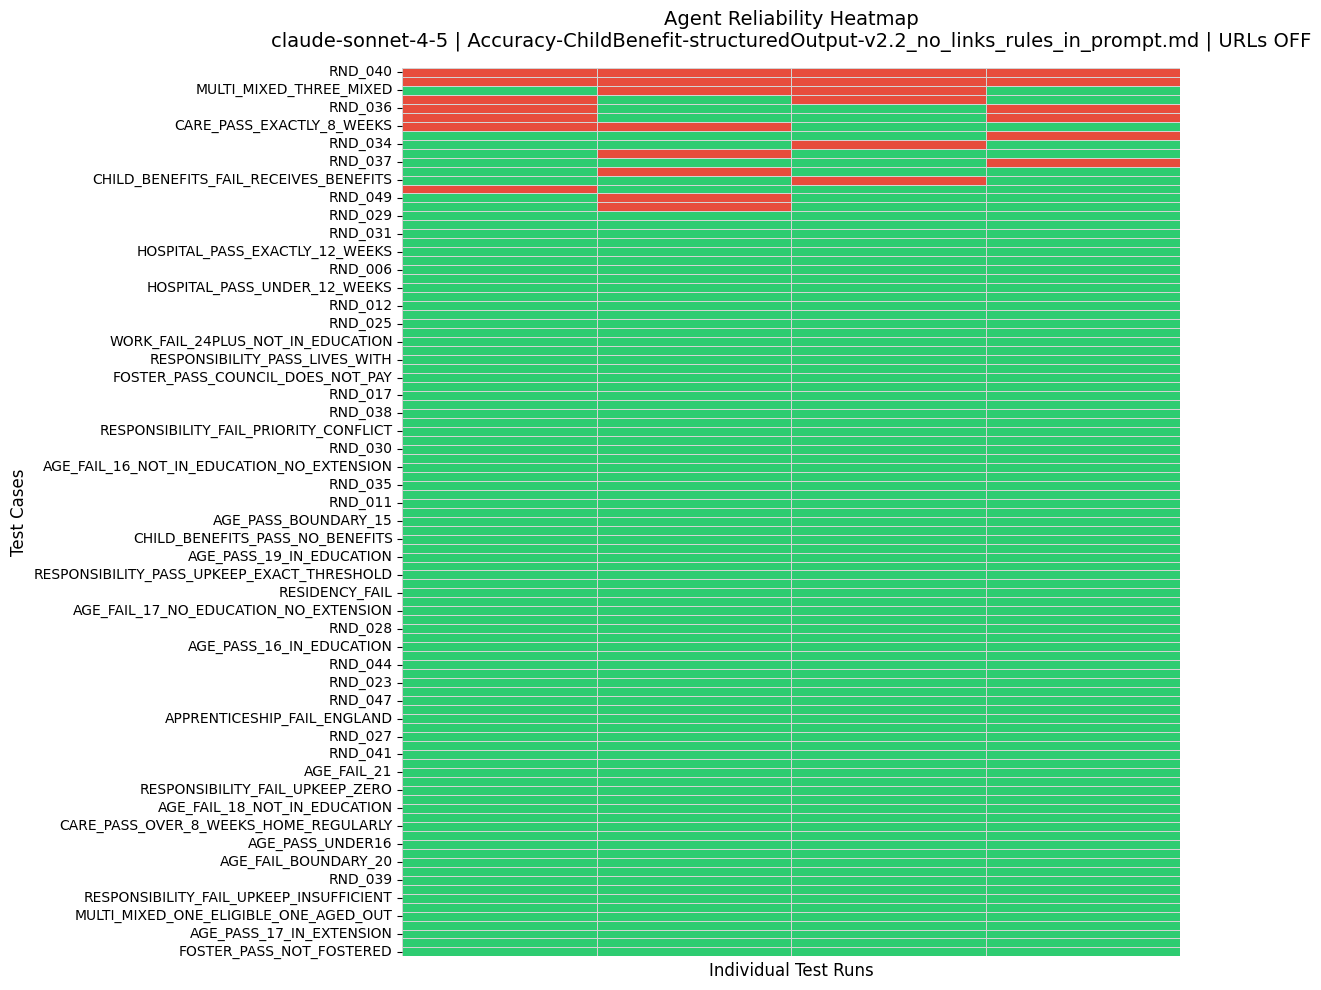

In [14]:
def plot_reliability_heatmaps(
    reliability_matrices: dict[tuple, pd.DataFrame],
) -> None:
    """
    Plot a reliability heatmap for each configuration.

    reliability_matrices:
        dict mapping config_key -> reliability dataframe
    """

    cmap = sns.color_palette(["#e74c3c", "#2ecc71"])

    for config_key, df_matrix in reliability_matrices.items():

        # Sort cases by pass rate
        df_sorted = df_matrix.sort_values("Pass_Rate")

        heatmap_data = (
            df_sorted
            .drop(columns=["Pass_Rate", "Category"], errors="ignore")
            .astype(float)
        )

        if heatmap_data.empty:
            continue

        model_name, prompt_name, urls_allowed = config_key
        url_label = "URLs ON" if urls_allowed else "URLs OFF"

        plt.figure(figsize=(12, 10))

        sns.heatmap(
            heatmap_data,
            cmap=cmap,
            cbar=False,
            linewidths=0.5,
            linecolor="lightgray",
            xticklabels=False,
        )

        plt.title(
            f"Agent Reliability Heatmap\n{model_name} | {prompt_name} | {url_label}",
            fontsize=14,
            pad=15,
        )

        plt.xlabel("Individual Test Runs", fontsize=12)
        plt.ylabel("Test Cases", fontsize=12)

        plt.tight_layout()
        plt.show()

plot_reliability_heatmaps(reliability_matrices)        